<a href="https://colab.research.google.com/github/patelmrunal/machine-learning-pytorch/blob/main/02_pytorch_neural_network_classification_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1 Make classification data and get it ready

In [1]:
# Neural Network Classification with PyTorch

import sklearn

In [2]:
from sklearn.datasets import make_circles

# Make sample
n_samples = 1000

# Create circle
x, y = make_circles(n_samples,
                    noise=0.04,
                    random_state=42)

In [3]:
len(x),  len(y)

(1000, 1000)

In [4]:
print(f"first 10 of x: {x[:10]}")
print(f"first 10 of y: {y[:10]}")

first 10 of x: [[ 0.74822656  0.23908325]
 [-0.74509559  0.16097526]
 [-0.82262532  0.19762051]
 [-0.41143316  0.68255648]
 [ 0.44390494 -0.89582949]
 [-0.47476593  0.69223611]
 [-0.01484687  0.80448601]
 [ 0.76556811  0.15364287]
 [-0.17250712 -0.79664632]
 [-0.11605096  1.03185826]]
first 10 of y: [1 1 1 1 0 1 1 1 1 0]


In [5]:
import pandas as pd

# Correctly create the DataFrame by passing a single dictionary
circles = pd.DataFrame({
    "X1": x[:, 0],
    "X2": x[:, 1],
    "label": y
})

circles.head(10)

,X1,X2,label
0,0.748227,0.239083,1
1,-0.745096,0.160975,1
2,-0.822625,0.197621,1
3,-0.411433,0.682556,1
4,0.443905,-0.895829,0
5,-0.474766,0.692236,1
6,-0.014847,0.804486,1
7,0.765568,0.153643,1
8,-0.172507,-0.796646,1
9,-0.116051,1.031858,0


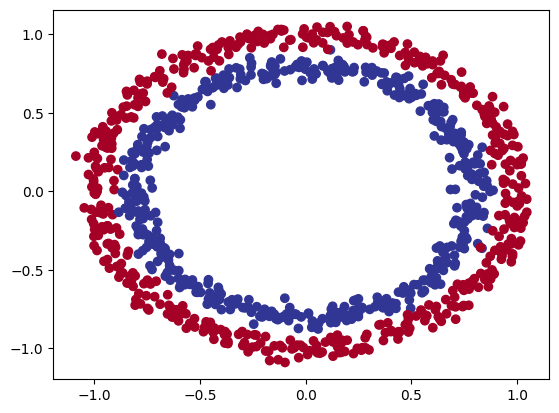

In [6]:
# Visualize
import matplotlib.pyplot as plt

plt.scatter(x = x[:,0],
            y = x[:,1],
            c = y,
            cmap = plt.cm.RdYlBu)

### 1.1 Check input and output shape

In [7]:
x.shape, y.shape

((1000, 2), (1000,))

In [8]:
x

array([[ 0.74822656,  0.23908325],
       [-0.74509559,  0.16097526],
       [-0.82262532,  0.19762051],
       ...,
       [-0.13256546, -0.8180725 ],
       [ 0.66563305, -0.78034584],
       [ 0.27973578,  0.96559198]])

In [9]:
# View the first example of feature and index

x_sample = x[0]
y_sample = y[0]

print(f"print value of sample sample X: {x_sample}, sample Y: {y_sample}")

print value of sample sample X: [0.74822656 0.23908325], sample Y: 1


### 1.2 Turn data into tensor and create train and test splits data

In [10]:
import torch
torch.__version__

'2.10.0+cu128'

In [11]:
type(x), type(y), x.dtype, y.dtype

(numpy.ndarray, numpy.ndarray, dtype('float64'), dtype('int64'))

In [12]:
import numpy as np

# Turn data into tensor only if they are numpy arrays
if isinstance(x, np.ndarray):
    x = torch.from_numpy(x).type(torch.float)
if isinstance(y, np.ndarray):
    y = torch.from_numpy(y).type(torch.float)

# View first 5 elements (slicing rows, not columns)
print(f"X: {x[:5]}")
print(f"y: {y[:5]}")

X: tensor([[ 0.7482,  0.2391],
        [-0.7451,  0.1610],
        [-0.8226,  0.1976],
        [-0.4114,  0.6826],
        [ 0.4439, -0.8958]])
y: tensor([1., 1., 1., 1., 0.])


In [13]:
type(x), type(y), x.dtype, y.dtype

(torch.Tensor, torch.Tensor, torch.float32, torch.float32)

In [14]:
# splits data into training and datasets

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.20, #20% data test and 85% data will be train
                                                    random_state=42)

len(x_train), len(x_test), len(y_train), len(y_test)

(800, 200, 800, 200)

##  2 Buliding a Model

In [15]:
import torch
from torch import  nn

In [16]:
# set up device
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [17]:
x_train.shape

torch.Size([800, 2])

In [18]:
# Make a model that subclass is nn.module
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # Create a nn.Linear layers
        self.layer_1 = nn.Linear(in_features= 2, out_features= 8)
        self.layer_2 = nn.Linear(in_features=8, out_features=1)

    # Defibe a forward method
    def forward(self, x):
        return self.layer_2(self.layer_1(x)) # x -> layer_1 -> layer_2

# Instantiate an instance of our model class
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=8, bias=True)
  (layer_2): Linear(in_features=8, out_features=1, bias=True)
)

In [19]:
device

'cuda'

In [20]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [21]:
# Replicate model using nn.sequential

model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=128),
    nn.Linear(in_features=128, out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=128, bias=True)
  (1): Linear(in_features=128, out_features=1, bias=True)
)

In [22]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.1851,  0.5585],
                      [-0.6984, -0.5961],
                      [-0.2910, -0.5288],
                      [ 0.4041, -0.0271],
                      [ 0.4248, -0.0844],
                      [-0.0741, -0.5233],
                      [-0.1284, -0.6795],
                      [ 0.6688,  0.5905],
                      [-0.6041,  0.6748],
                      [-0.5314, -0.4921],
                      [-0.7015,  0.2829],
                      [ 0.2313,  0.1355],
                      [-0.0156, -0.3760],
                      [-0.1203, -0.1539],
                      [-0.6054,  0.4481],
                      [ 0.0119, -0.0907],
                      [-0.1117,  0.2458],
                      [ 0.1443, -0.0036],
                      [-0.4268,  0.6720],
                      [-0.3238, -0.5410],
                      [ 0.4136,  0.0491],
                      [ 0.0010, -0.4871],
                      [-0.2937,  0.1781],
        

In [23]:
# Make Predctions
with torch.inference_mode():
    untrained_preds = model_0(x_test.to(device))
print(f"untrained preds: {len(untrained_preds)}, shape: {untrained_preds.shape}")
print(f"lenght of test sample {len(x_test)}, shape: {x_test.shape}")
print(f"First 20 preds: \n{torch.round(untrained_preds[:10])}")
print(f"First 20 labels: \n {y_test[:10]}")

untrained preds: 200, shape: torch.Size([200, 1])
lenght of test sample 200, shape: torch.Size([200, 2])
First 20 preds: 
tensor([[0.],
        [1.],
        [-0.],
        [1.],
        [-0.],
        [-0.],
        [0.],
        [0.],
        [-0.],
        [1.]], device='cuda:0')
First 20 labels: 
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


### 2.1 Set up loss function and optimizer

In [24]:
# Setup the loss function

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [25]:
# Calculate the accuracy

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

## 3 Train model

In [26]:
## View the first 5 output of the forward pass on test data

model_0.eval()
with torch.inference_mode():
  y_logits = model_0(x_test.to(device))[:5]
y_logits

tensor([[ 0.3875],
        [ 0.5496],
        [-0.1816],
        [ 0.5582],
        [-0.4175]], device='cuda:0')

In [27]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [28]:
# Use the sigmoid activation function on our model logits

y_preds_probs = torch.sigmoid(y_logits)
y_preds_probs

tensor([[0.5957],
        [0.6341],
        [0.4547],
        [0.6360],
        [0.3971]], device='cuda:0')

In [29]:
# Find the predicted labels
y_preds = torch.round(y_preds_probs)

# In full
y_preds_label = torch.round(torch.sigmoid(model_0(x_test.to(device))[:5]))

# Check for quality
print(torch.eq(y_preds.squeeze(), y_preds_label.squeeze()))

y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([1., 1., 0., 1., 0.], device='cuda:0')

### 3.1 Buliding Testing and Training loop

In [30]:
torch.cuda.manual_seed(42)

epochs = 100

# Put data to the target device
x_train, y_train = x_train.to(device), y_train.to(device)
x_test, y_test = x_test.to(device), y_test.to(device)

# Buliding training and evaluation loop
for epoch in range(epochs):
    # Training
    model_0.train()

    # 1. Forward pass
    y_logits = model_0(x_train).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits))

    #2. Calculate the loss
    ###loss = loss_fn(torch.sigmoid(y_logits), y_train)
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_preds)

    #3. Optimizer zero
    optimizer.zero_grad()

    #4. Loss backward
    loss.backward()

    #5. optimizer step
    optimizer.step()

    # Testing
    model_0.eval()
    with torch.inference_mode():
        # Forward pass
        test_logits = model_0(x_test).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))

        # Calculate the loss/acc
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_preds)

    # Print out what happen
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.70651 | Acc: 50.88% | Test Loss: 0.71333 | Test Acc: 47.00%
Epoch: 10 | Loss: 0.69305 | Acc: 51.25% | Test Loss: 0.69551 | Test Acc: 46.00%
Epoch: 20 | Loss: 0.69298 | Acc: 51.38% | Test Loss: 0.69474 | Test Acc: 45.50%
Epoch: 30 | Loss: 0.69298 | Acc: 51.38% | Test Loss: 0.69468 | Test Acc: 45.50%
Epoch: 40 | Loss: 0.69298 | Acc: 51.38% | Test Loss: 0.69467 | Test Acc: 45.50%
Epoch: 50 | Loss: 0.69298 | Acc: 51.38% | Test Loss: 0.69467 | Test Acc: 45.50%
Epoch: 60 | Loss: 0.69298 | Acc: 51.38% | Test Loss: 0.69467 | Test Acc: 45.50%
Epoch: 70 | Loss: 0.69298 | Acc: 51.38% | Test Loss: 0.69467 | Test Acc: 45.50%
Epoch: 80 | Loss: 0.69298 | Acc: 51.38% | Test Loss: 0.69467 | Test Acc: 45.50%
Epoch: 90 | Loss: 0.69298 | Acc: 51.38% | Test Loss: 0.69467 | Test Acc: 45.50%


##  4 Make predictions and evaluate the model



In [31]:
import requests
from pathlib import Path

# Download helper function from PyTorch repo

if Path("helper_functions.py").is_file():
    print("helper_functions.py already exists, skipping download")
else:
    print("Downloading helper_functions.py")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
    with open("helper_functions.py", "wb") as f:
        f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

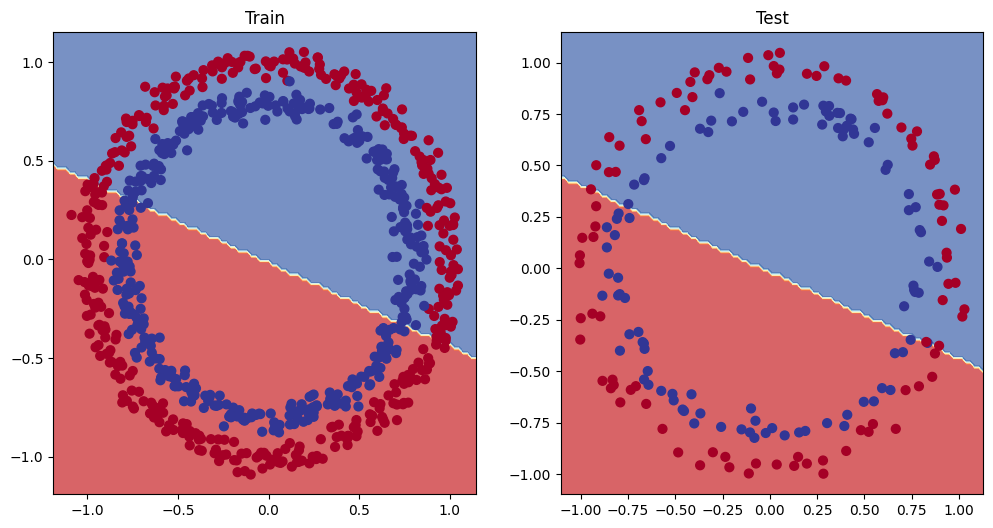

In [32]:
# Plot decision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, x_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, x_test, y_test)

## 5 Improving a model (from a model perspective)

In [33]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=128)
    self.layer_2 = nn.Linear(in_features=128, out_features=128)
    self.layer_3 = nn.Linear(in_features=128, out_features=1)

  def forward(self, x):
    return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=128, bias=True)
  (layer_2): Linear(in_features=128, out_features=128, bias=True)
  (layer_3): Linear(in_features=128, out_features=1, bias=True)
)

In [34]:
# Create a loss function
loss_fn = nn.BCEWithLogitsLoss()

# Create an optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

In [35]:
torch.cuda.manual_seed(42)

epochs = 1000

# Put the data to the trget device
x_test, y_test = x_test.to(device), y_test.to(device)
x_train, y_train = x_train.to(device), y_train.to(device)

for epoch in range(epochs):
    # Training
    model_1.train()

    # 1. Forward pass
    y_logits = model_1(x_train).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits))

    #2. calculate the loss
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_preds)

    #3. optimizer zero
    optimizer.zero_grad()

    #4. loss backward
    loss.backward()

    #5. optimizer step
    optimizer.step()

    # Testing
    model_1.eval()
    with torch.inference_mode():
        ## Forward pass
        test_logits = model_1(x_test).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))

        # Calculate the loss/acc
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_preds)

    # Print out what happen
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69442 | Acc: 48.12% | Test Loss: 0.69629 | Test Acc: 49.00%
Epoch: 100 | Loss: 0.69298 | Acc: 51.38% | Test Loss: 0.69467 | Test Acc: 45.50%
Epoch: 200 | Loss: 0.69298 | Acc: 51.38% | Test Loss: 0.69467 | Test Acc: 45.50%
Epoch: 300 | Loss: 0.69298 | Acc: 51.38% | Test Loss: 0.69467 | Test Acc: 45.50%
Epoch: 400 | Loss: 0.69298 | Acc: 51.38% | Test Loss: 0.69467 | Test Acc: 45.50%
Epoch: 500 | Loss: 0.69298 | Acc: 51.38% | Test Loss: 0.69467 | Test Acc: 45.50%
Epoch: 600 | Loss: 0.69298 | Acc: 51.38% | Test Loss: 0.69467 | Test Acc: 45.50%
Epoch: 700 | Loss: 0.69298 | Acc: 51.38% | Test Loss: 0.69467 | Test Acc: 45.50%
Epoch: 800 | Loss: 0.69298 | Acc: 51.38% | Test Loss: 0.69467 | Test Acc: 45.50%
Epoch: 900 | Loss: 0.69298 | Acc: 51.38% | Test Loss: 0.69467 | Test Acc: 45.50%


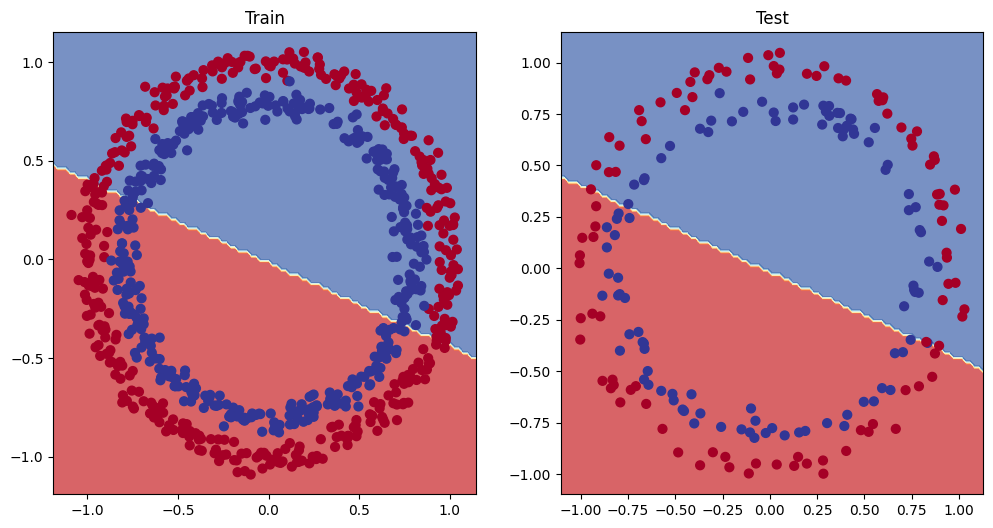

In [36]:
# Plot decision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, x_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, x_test, y_test)

### 5.1 Preparing a data to see if our model fit a straight line

In [37]:
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

x_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * x_regression + bias

print(len(x_regression))
x_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [38]:
# Split the data
train_split = int(0.8 * len(x_regression))
x_train_reg, y_train_reg = x_regression[:train_split], y_regression[:train_split]
x_test_reg, y_test_reg = x_regression[train_split:], y_regression[train_split:]
print(f"len(x_train_reg): {len(x_train_reg)}, len(y_train_reg): {len(y_train_reg)}")
print(f"len(x_test_reg): {len(x_test_reg)}, len(y_test_reg): {len(y_test_reg)}")

len(x_train_reg): 80, len(y_train_reg): 80
len(x_test_reg): 20, len(y_test_reg): 20


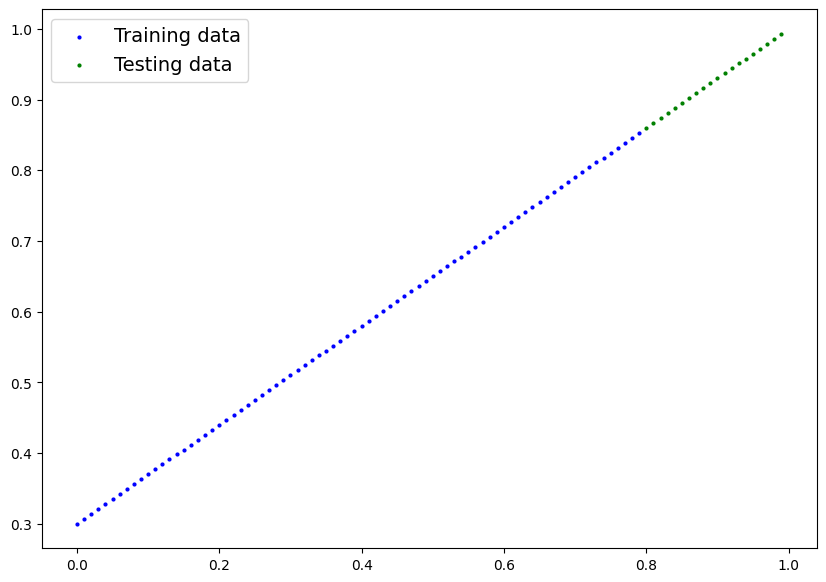

In [39]:
plot_predictions(train_data=x_train_reg,
                 train_labels=y_train_reg,
                 test_data=x_test_reg,
                 test_labels=y_test_reg,
                 predictions=None)

### 5.2 Adjusting a "model_1" to fit a straight line

In [40]:
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=128),
    nn.Linear(in_features=128, out_features=128),
    nn.Linear(in_features=128, out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=128, bias=True)
  (1): Linear(in_features=128, out_features=128, bias=True)
  (2): Linear(in_features=128, out_features=1, bias=True)
)

In [41]:
# Loss and optimizer
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.01)

In [42]:
# Train the model

torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

# Put the data into the target device
x_train_reg, y_train_reg = x_train_reg.to(device), y_train_reg.to(device)
x_test_reg, y_test_reg = x_test_reg.to(device), y_test_reg.to(device)

for epoch in range(epochs):

    #Forward pass
    y_preds = model_2(x_train_reg)

    # Calculate the loss
    loss = loss_fn(y_preds, y_train_reg)

    # Optimizer zero
    optimizer.zero_grad()

    #Backpropagation
    loss.backward()

    # Optimizer step
    optimizer.step()

    model_2.eval()
    with torch.inference_mode():
        test_preds = model_2(x_test_reg).squeeze()
        test_loss = loss_fn(test_preds, y_test_reg)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:129: UserWarning: Using a target size (torch.Size([20, 1])) that is different to the input size (torch.Size([20])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


Epoch: 0 | Loss: 0.74761 | Test Loss: 0.69276
Epoch: 100 | Loss: 0.12057 | Test Loss: 0.04519
Epoch: 200 | Loss: 0.09010 | Test Loss: 0.04510
Epoch: 300 | Loss: 0.06112 | Test Loss: 0.04293
Epoch: 400 | Loss: 0.05953 | Test Loss: 0.04402
Epoch: 500 | Loss: 0.05922 | Test Loss: 0.04502
Epoch: 600 | Loss: 0.03481 | Test Loss: 0.06444
Epoch: 700 | Loss: 0.00282 | Test Loss: 0.09215
Epoch: 800 | Loss: 0.04769 | Test Loss: 0.05345
Epoch: 900 | Loss: 0.02582 | Test Loss: 0.06699


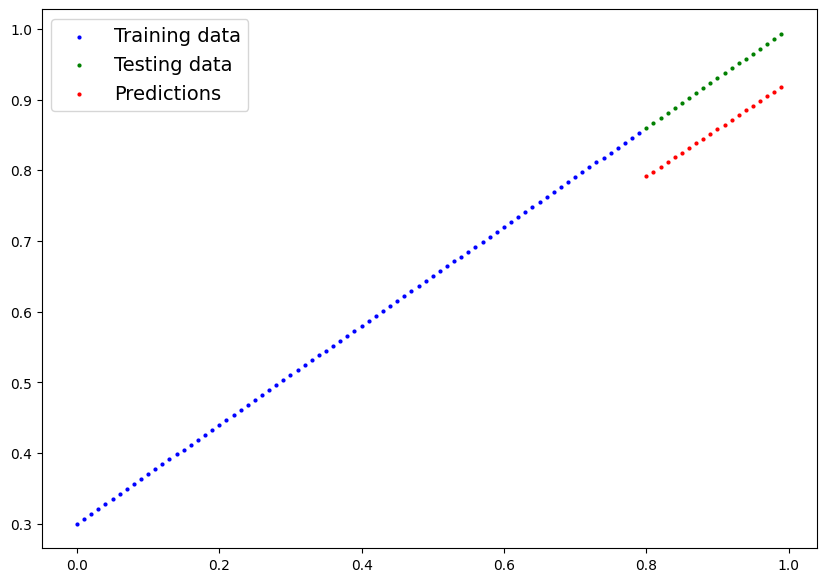

In [43]:
# Turn on evaluation mode

model_2.eval()

with torch.inference_mode():
    y_preds = model_2(x_test_reg)
    test_loss = loss_fn(y_preds, y_test_reg)

plot_predictions(train_data=x_train_reg.cpu(),
                 train_labels=y_train_reg.cpu(),
                 test_data=x_test_reg.cpu(),
                 test_labels=y_test_reg.cpu(),
                 predictions=y_preds.cpu())

## 6 The Missing piece: non-linearity

### 6.1 Recreating non-linear data (red and blue circles)

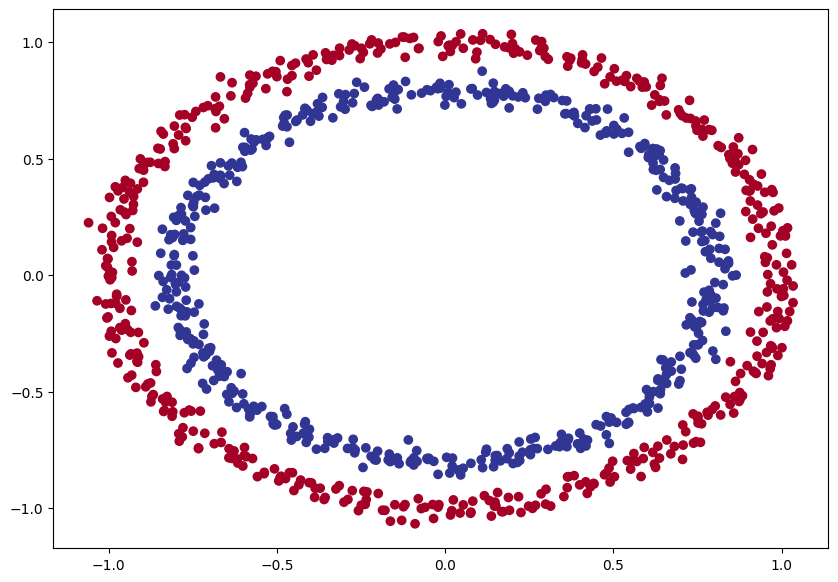

In [44]:
# Make and plot data

import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

x, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

plt.figure(figsize=(10, 7))
plt.scatter(x = x[:,0],
            y = x[:,1],
            c = y,
            cmap = plt.cm.RdYlBu)

In [45]:
# Convert data to tensors and then to train and test splits

import torch
from sklearn.model_selection import train_test_split

x = torch.from_numpy(x).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.20, #20% data test and 80% data will be train
                                                    random_state=42)
x_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### 6.2 Building a model with non-linearity

In [46]:
from torch import nn

class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=128)
    self.layer_2 = nn.Linear(in_features=128, out_features=128)
    self.layer_3 = nn.Linear(in_features=128, out_features=1)
    self.relu = nn.ReLU()

  def forward(self, x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=128, bias=True)
  (layer_2): Linear(in_features=128, out_features=128, bias=True)
  (layer_3): Linear(in_features=128, out_features=1, bias=True)
  (relu): ReLU()
)

In [47]:
# Set up loss and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_3.parameters(), lr=0.1)

### 6.3 Training a model with non-linearity

In [48]:
# Random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Put all data to same device
x_train, y_train = x_train.to(device), y_train.to(device)
x_test, y_test = x_test.to(device), y_test.to(device)

# Loop through data

epochs = 1000

for epoch in range(epochs):
    model_3.train()

    #1. Forward pass
    y_logits = model_3(x_train).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits))

    #2. Calculate the loss
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_preds)

    #3.optimizer zero grad
    optimizer.zero_grad()

    #4. loss backward
    loss.backward()

    #5. optimizer step
    optimizer.step()

    # Testing
    model_3.eval()
    with torch.inference_mode():
        test_logits = model_3(x_test).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_preds)

    # Print out
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69356 | Acc: 50.00% | Test Loss: 0.69433 | Test Acc: 50.00%
Epoch: 100 | Loss: 0.66885 | Acc: 79.38% | Test Loss: 0.67405 | Test Acc: 79.00%
Epoch: 200 | Loss: 0.61478 | Acc: 97.12% | Test Loss: 0.62874 | Test Acc: 91.50%
Epoch: 300 | Loss: 0.48201 | Acc: 99.00% | Test Loss: 0.51379 | Test Acc: 98.00%
Epoch: 400 | Loss: 0.28199 | Acc: 99.62% | Test Loss: 0.32896 | Test Acc: 99.00%
Epoch: 500 | Loss: 0.15238 | Acc: 100.00% | Test Loss: 0.19601 | Test Acc: 100.00%
Epoch: 600 | Loss: 0.08500 | Acc: 100.00% | Test Loss: 0.12123 | Test Acc: 100.00%
Epoch: 700 | Loss: 0.05468 | Acc: 100.00% | Test Loss: 0.08461 | Test Acc: 100.00%
Epoch: 800 | Loss: 0.03880 | Acc: 100.00% | Test Loss: 0.06440 | Test Acc: 100.00%
Epoch: 900 | Loss: 0.02948 | Acc: 100.00% | Test Loss: 0.05204 | Test Acc: 100.00%


### 6.4 Evaluating a model trained with non-linear activation functions

In [49]:
# Make predictions
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_3(x_test))).squeeze()

y_preds[:10], y_test[:10]

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'))

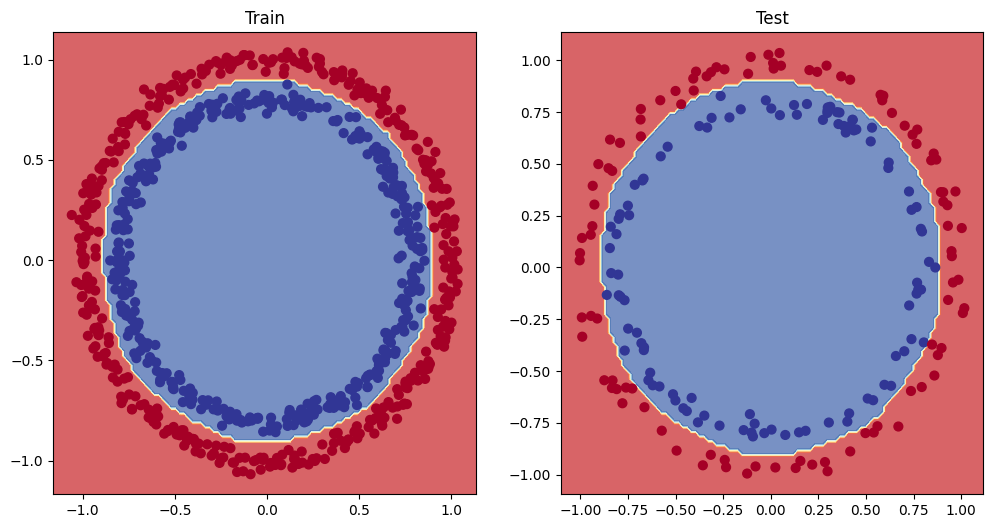

In [50]:
# Plot desicion boundaries
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, x_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, x_test, y_test)

## 7 Replicating non-linear activation function

In [51]:
# Create a tesnor

A = torch.arange(-10, 10, 1, dtype=torch.float32)
A.dtype

torch.float32

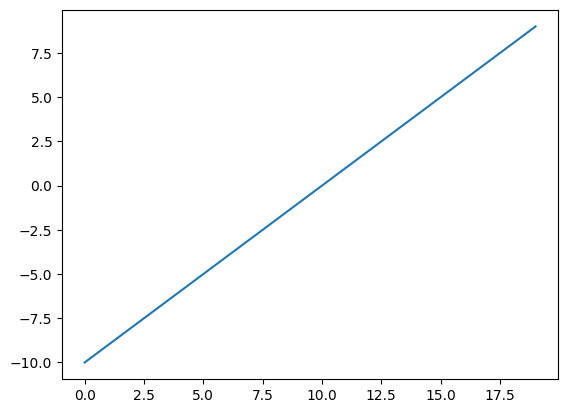

In [52]:
plt.plot(A)

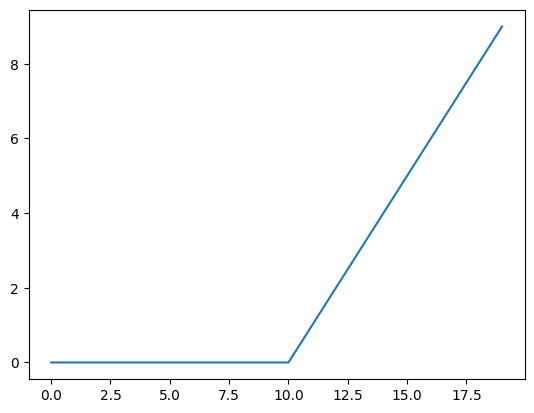

In [53]:
plt.plot(torch.relu(A))

In [54]:
def relu(x: torch.Tensor) -> torch.Tensor:
    return torch.maximum(torch.tensor(0), x)

relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

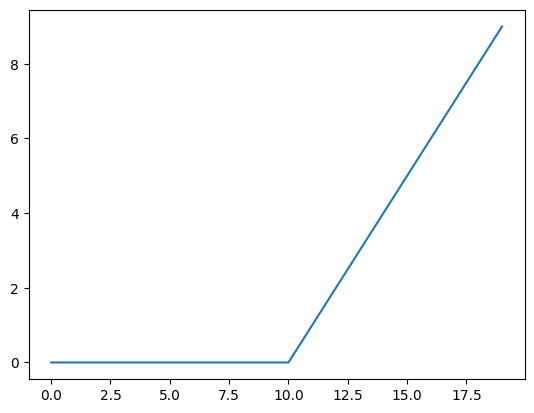

In [55]:
plt.plot(relu(A))

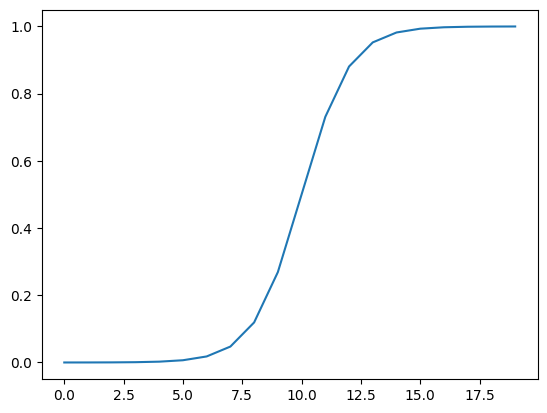

In [56]:
plt.plot(torch.sigmoid(A))

## 8 Putting it all together with a multi-class classification problem

### 8.2 Creating a toy multi-class datasets

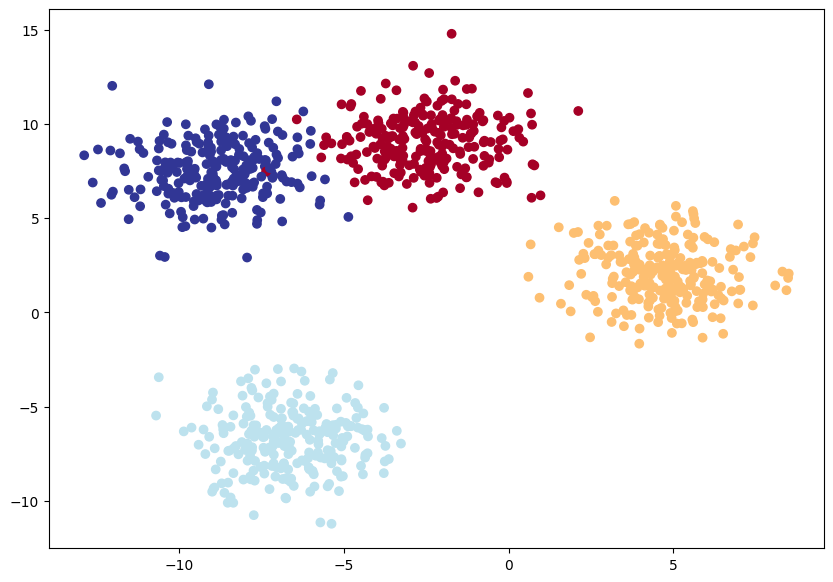

In [57]:
import torch
from matplotlib import pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

#1. Create the data
X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES,
                            centers=NUM_CLASSES,
                            cluster_std=1.5,
                            random_state=RANDOM_SEED)

#2. Turn data into tensors
x_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.float)

#3. split into train and test
x_blob_train, x_blob_test, y_blob_train, y_blob_test = train_test_split(x_blob,
                                                                        y_blob,
                                                                        test_size=0.2,
                                                                        random_state= RANDOM_SEED)

#4. Plot data
plt.figure(figsize=(10,7))
plt.scatter(x=X_blob[:,0],
            y=X_blob[:,1],
            c=y_blob,
            cmap=plt.cm.RdYlBu)

### 8.3 Building a multi-class classification model

In [58]:
# Create a device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [59]:
# Build a multi-class classification model

class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_features),
    )

  def forward(self, x):
    return self.linear_layer_stack(x)

# Create an instance for BlobModel and send it to the target device
model_4 = BlobModel(input_features=2, output_features=4, hidden_units=8).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [60]:
x_blob_train.shape, y_blob_train[:5]

(torch.Size([800, 2]), tensor([1., 0., 2., 2., 0.]))

In [61]:
torch.unique(y_blob_train)

tensor([0., 1., 2., 3.])

### 8.4 Create a loss function and an optimizer for a multi-class classification model

In [62]:
# Create a loss function for multi-class classification model
loss_fn = nn.CrossEntropyLoss()

# Create an optimizer
optimizer = torch.optim.SGD(params=model_4.parameters(), lr=0.1)

### 8.5 Getting predication probabilities for a multi-class classification model

In [63]:
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(x_blob_test.to(device))
y_logits[:10]

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834],
        [-0.1497, -1.0617, -0.7107, -0.1645],
        [ 0.1539, -0.2887,  0.1520, -0.0109],
        [-0.2154, -1.1795, -0.9300, -0.2745],
        [ 0.2443, -0.2472,  0.1649,  0.0061],
        [-0.2329, -1.2120, -0.9849, -0.3004]], device='cuda:0')

In [64]:
y_blob_test[:10]

tensor([1., 3., 2., 1., 0., 3., 2., 0., 2., 0.])

In [65]:
# Convert our mpodel's logit outputs
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:10])
print(y_pred_probs[:10])

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834],
        [-0.1497, -1.0617, -0.7107, -0.1645],
        [ 0.1539, -0.2887,  0.1520, -0.0109],
        [-0.2154, -1.1795, -0.9300, -0.2745],
        [ 0.2443, -0.2472,  0.1649,  0.0061],
        [-0.2329, -1.2120, -0.9849, -0.3004]], device='cuda:0')
tensor([[0.3169, 0.3244, 0.1405, 0.2182],
        [0.3336, 0.1432, 0.2026, 0.3206],
        [0.3011, 0.1843, 0.2823, 0.2323],
        [0.3078, 0.2766, 0.1836, 0.2320],
        [0.3719, 0.1286, 0.1532, 0.3463],
        [0.3381, 0.1358, 0.1929, 0.3331],
        [0.2867, 0.1841, 0.2861, 0.2431],
        [0.3554, 0.1355, 0.1740, 0.3351],
        [0.3009, 0.1841, 0.2779, 0.2371],
        [0.3595, 0.1350, 0.1695, 0.3360]], device='cuda:0')


In [66]:
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds

tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 3, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 1, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 1, 0, 1], device='cuda:0')

In [67]:
y_blob_test

tensor([1., 3., 2., 1., 0., 3., 2., 0., 2., 0., 0., 1., 0., 0., 0., 3., 3., 2.,
        3., 3., 3., 0., 1., 2., 2., 2., 3., 0., 1., 0., 3., 1., 1., 3., 1., 2.,
        1., 3., 0., 2., 0., 3., 3., 2., 0., 3., 1., 1., 0., 3., 1., 0., 1., 1.,
        3., 2., 1., 1., 3., 2., 2., 0., 3., 2., 2., 0., 0., 3., 3., 0., 0., 3.,
        3., 3., 2., 3., 3., 3., 3., 1., 0., 2., 3., 2., 3., 3., 2., 3., 3., 2.,
        3., 3., 1., 3., 3., 3., 1., 0., 3., 2., 0., 0., 3., 0., 2., 3., 1., 0.,
        3., 2., 1., 1., 0., 2., 2., 3., 0., 0., 1., 2., 2., 3., 0., 1., 2., 0.,
        0., 0., 2., 3., 1., 2., 3., 2., 0., 3., 0., 0., 1., 1., 1., 0., 2., 2.,
        2., 2., 0., 3., 3., 2., 2., 1., 3., 2., 0., 0., 3., 3., 2., 1., 2., 0.,
        3., 2., 0., 3., 2., 0., 2., 2., 2., 0., 3., 1., 1., 1., 1., 1., 3., 1.,
        0., 2., 2., 1., 2., 2., 0., 1., 2., 2., 0., 0., 1., 3., 2., 0., 3., 1.,
        2., 1.])

### 8.6 Create a training loop and testing loop for multi-class PyTorch model

In [70]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

# Put data to the target device
x_blob_train, y_blob_train = x_blob_train.to(device), y_blob_train.to(device)
x_blob_test, y_blob_test = x_blob_test.to(device), y_blob_test.to(device)

# Loop through data
for epoch in range(epochs):
  model_4.train()

  #1. Forward Pass
  y_logits = model_4(x_blob_train)
  y_preds = torch.softmax(y_logits, dim=1).argmax(dim=1)

  #2. Calculate the loss
  loss = loss_fn(y_logits, y_blob_train.long())
  acc = accuracy_fn(y_true=y_blob_train.long(), y_pred=y_preds)

  #3. optimizer zerograd
  optimizer.zero_grad()

  #4. loss backward
  loss.backward()

  #5. optimizer step
  optimizer.step()

  model_4.eval()
  with torch.inference_mode():
    test_logits = model_4(x_blob_test)
    test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)
    test_loss = loss_fn(test_logits, y_blob_test.long())
    test_acc = accuracy_fn(y_true=y_blob_test.long(), y_pred=test_preds)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.15883 | Acc: 40.38% | Test Loss: 1.07554 | Test Acc: 48.00%
Epoch: 100 | Loss: 0.03312 | Acc: 99.25% | Test Loss: 0.02433 | Test Acc: 99.50%
Epoch: 200 | Loss: 0.02657 | Acc: 99.25% | Test Loss: 0.01651 | Test Acc: 99.50%
Epoch: 300 | Loss: 0.02503 | Acc: 99.25% | Test Loss: 0.01440 | Test Acc: 99.50%
Epoch: 400 | Loss: 0.02427 | Acc: 99.25% | Test Loss: 0.01335 | Test Acc: 99.50%
Epoch: 500 | Loss: 0.02377 | Acc: 99.25% | Test Loss: 0.01269 | Test Acc: 99.50%
Epoch: 600 | Loss: 0.02339 | Acc: 99.25% | Test Loss: 0.01218 | Test Acc: 99.50%
Epoch: 700 | Loss: 0.02307 | Acc: 99.25% | Test Loss: 0.01179 | Test Acc: 99.50%
Epoch: 800 | Loss: 0.02279 | Acc: 99.25% | Test Loss: 0.01147 | Test Acc: 99.50%
Epoch: 900 | Loss: 0.02253 | Acc: 99.25% | Test Loss: 0.01120 | Test Acc: 99.50%


### 8.7 Making a predictions with a PyTorch multi-class model

In [71]:
# Make a predictions
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(x_blob_test)

y_logits[:10]

tensor([[ -2.3751,  10.9387, -10.2038, -11.3271],
        [ -2.1934,  -9.4839,  -6.3062,   5.2289],
        [ -4.9855,  -5.3790,   5.3840,  -4.3115],
        [ -3.0428,   8.1532,  -5.4971,  -6.6867],
        [  6.4903,  -2.8976, -12.3324,  -8.4675],
        [ -2.7724, -11.1928,  -7.4741,   6.3900],
        [ -4.3608,  -4.5814,   4.6890,  -3.5910],
        [  5.8017,  -6.8308,  -9.7351,  -4.1265],
        [ -6.3789,  -6.9228,   6.6638,  -5.5251],
        [  6.2822,  -5.5357, -10.3558,  -5.4748]], device='cuda:0')

In [72]:
y_pred_probs = torch.softmax(y_logits, dim=1)
y_pred_probs[:10]

tensor([[1.6516e-06, 1.0000e+00, 6.5756e-10, 2.1386e-10],
        [5.9742e-04, 4.0743e-07, 9.7751e-06, 9.9939e-01],
        [3.1372e-05, 2.1166e-05, 9.9989e-01, 6.1553e-05],
        [1.3729e-05, 9.9998e-01, 1.1797e-06, 3.5901e-07],
        [9.9992e-01, 8.3727e-05, 6.6890e-09, 3.1907e-07],
        [1.0490e-04, 2.3113e-08, 9.5250e-07, 9.9989e-01],
        [1.1735e-04, 9.4122e-05, 9.9954e-01, 2.5340e-04],
        [9.9995e-01, 3.2640e-06, 1.7882e-07, 4.8777e-05],
        [2.1657e-06, 1.2571e-06, 9.9999e-01, 5.0864e-06],
        [9.9998e-01, 7.3711e-06, 5.9456e-08, 7.8340e-06]], device='cuda:0')

In [73]:
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')

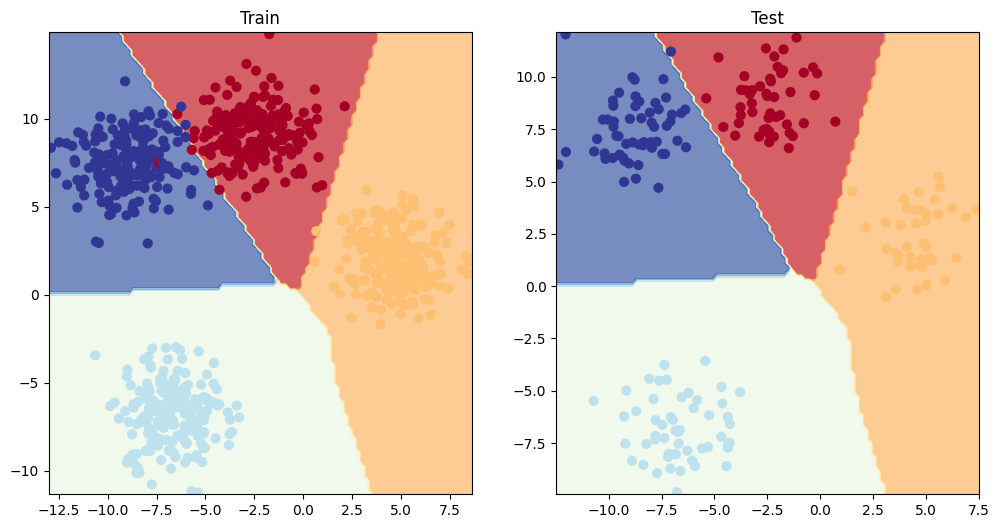

In [75]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, x_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, x_blob_test, y_blob_test)

## 9 A few more model train

In [77]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 27.7 MB/s eta 0:00:00


In [81]:
from torchmetrics import Accuracy

#set-up matrics
torchmetric_accuracy = Accuracy(task="multiclass", num_classes=4).to(device)

#calculate accuracy
torchmetric_accuracy(y_preds, y_blob_test)

tensor(0.9950, device='cuda:0')